In [21]:
import yfinance as yf
import pandas as pd

oil_price = yf.download("CL=F", start="2018-01-01", end="2025-01-01")['Close']
oil_vol = yf.download("^OVX", start="2018-01-01", end="2025-01-01")['Close']
oil_price = oil_price.rename(columns={'CL=F': 'Oil_Price'})
oil_vol = oil_vol.rename(columns={'^OVX': 'Oil_Vol'})

/var/folders/_q/9tmf12095cn84735n3vm06sm0000gn/T/ipykernel_33413/3387428247.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_price = yf.download("CL=F", start="2018-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/_q/9tmf12095cn84735n3vm06sm0000gn/T/ipykernel_33413/3387428247.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_vol = yf.download("^OVX", start="2018-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


In [22]:
oil_vol['Oil_Vol'] = oil_vol['Oil_Vol']/100
oil_data = pd.merge(oil_price, oil_vol, on='Date')
oil_data['Oil_Price'] = oil_data['Oil_Price'].mask(oil_data['Oil_Price'] < 0, np.nan)
oil_data['Oil_Price'] = oil_data['Oil_Price'].ffill()
oil_data


Ticker,Oil_Price,Oil_Vol
Date,,
2018-01-02,60.369999,0.2273
2018-01-03,61.630001,0.2275
2018-01-04,62.009998,0.2212
2018-01-05,61.439999,0.2230
2018-01-08,61.730000,0.2190
...,...,...
2024-12-24,70.099998,0.3035
2024-12-26,69.620003,0.3001
2024-12-27,70.599998,0.3021


In [23]:
from fredapi import Fred
import datetime
import numpy as np

start = datetime.datetime(2018, 1, 1)
end = datetime.datetime(2025, 12, 1)
fred = Fred(api_key="38cb01394acc36b6a9f9178338c51d8d")

r_series = fred.get_series('DGS1MO', start, end)
rf_df = r_series.to_frame(name='rf_rate')
rf_df['rf_rate'] = (rf_df['rf_rate']/100).ffill()
rf_df['rf'] = np.log(1 + rf_df['rf_rate'])
rf_df = rf_df.reset_index()
rf_df = rf_df.rename(columns={'index': 'Date'})

oil_data = oil_data.merge(rf_df[['Date', 'rf']], on='Date')

In [35]:
import numpy as np
from scipy.stats import norm

def Oil_Pricer_Call(F, K, r, sigma, T=30/365):
    d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    
    return call_price

def Oil_Pricer_Put(F, K, r, sigma, T=30/365):
    d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    
    return put_price

calls = []
puts = []
strikes = []

for i in range(len(oil_data)):
    legit_strike = round(oil_data['Oil_Price'].iloc[i] * 2) / 2
    strikes.append(legit_strike)
    calls.append(Oil_Pricer_Call(oil_data['Oil_Price'].iloc[i], legit_strike, oil_data['rf'].iloc[i], oil_data['Oil_Vol'].iloc[i]))
    puts.append(Oil_Pricer_Put(oil_data['Oil_Price'].iloc[i], legit_strike, oil_data['rf'].iloc[i], oil_data['Oil_Vol'].iloc[i]))

oil_data['ATM Call Price'] = calls
oil_data['ATM Put Price'] = puts
oil_data.to_csv('Oil_data.csv')


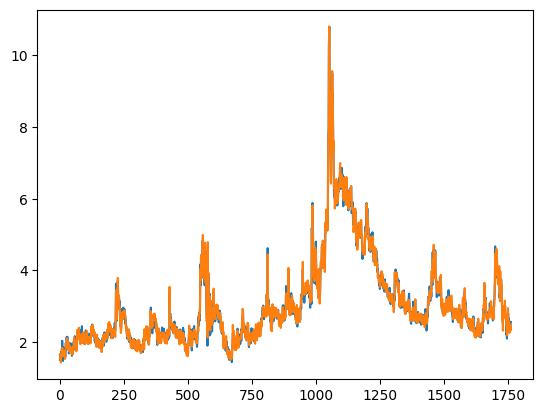

In [33]:
import matplotlib.pyplot as plt

plt.plot(oil_data['ATM Call Price'])
plt.plot(oil_data['ATM Put Price'])
